<table class="table table-bordered">
    <tr>
        <th style="text-align:center; width:25%"><img src='https://www.np.edu.sg/PublishingImages/Pages/default/odp/ICT.jpg' style="width: 250px; height: 125px; "></th>
        <th style="text-align:center;"><h1>Deep Learning</h1><h2>Assignment 2 - Character Generator Model (Problem 2)</h2><h3>AY2020/21 Semester</h3></th>
    </tr>
</table>

In [1]:
# Import the Required Packages
# Enter your code here:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras import regularizers
from tensorflow.keras.layers import GRU, LSTM
from keras.regularizers import l2
from keras.regularizers import l1
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense, Masking, Dropout
import numpy as np
import random

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

Using TensorFlow backend.


## Step 1 – Data Loading and Processing

### 1.1 Data Loading

In [11]:
# read in the text file, transforming everything to lower case
text = open('holmes.txt').read().lower()
print('The original text has ' + str(len(text)) + ' characters.\n')

The original text has 562422 characters.



### 1.2 Data Processing


In [12]:
### print out the first 1000 characters of the raw text to get a sense of what characters to remove
text[:2000]

"\ufeffthe adventures of sherlock holmes by sir arthur conan doyle\n\n   i. a scandal in bohemia\n  ii. the red-headed league\n iii. a case of identity\n  iv. the boscombe valley mystery\n   v. the five orange pips\n  vi. the man with the twisted lip\n vii. the adventure of the blue carbuncle\nviii. the adventure of the speckled band\n  ix. the adventure of the engineer's thumb\n   x. the adventure of the noble bachelor\n  xi. the adventure of the beryl coronet\n xii. the adventure of the copper beeches\n\n\nadventure i. a scandal in bohemia\n\ni.\n\nto sherlock holmes she is always the woman. i have seldom heard\nhim mention her under any other name. in his eyes she eclipses\nand predominates the whole of her sex. it was not that he felt\nany emotion akin to love for irene adler. all emotions, and that\none particularly, were abhorrent to his cold, precise but\nadmirably balanced mind. he was, i take it, the most perfect\nreasoning and observing machine that the world has seen, but as

In [13]:
# remove all '\n' and '\r' from text
text = text.replace('\n',' ') 
text = text.replace('\r',' ')

In [14]:
# create a function 'clean_text' to clean text so that only the following letters and punctation remain
def clean_text(text):
    punctuation = ['!', ',', '.', ':', ';', '?', '-', "'",' ']
    letters='abcdefghijklmnopqrstuvwxyz'
    letterList=list(letters)
    
    # Enter your code here:
    for character in text:
        if (character in punctuation) or (character in letterList):
            continue
        else:
            text = text.replace(character, "")
    
    text = ' '.join(text.split())
    
    toreplace = """i. a scandal in bohemia ii. the red-headed league iii. a case of identity iv. the boscombe valley mystery v. the five orange pips vi. the man with the twisted lip vii. the adventure of the blue carbuncle viii. the adventure of the speckled band ix. the adventure of the engineer's thumb x. the adventure of the noble bachelor xi. the adventure of the beryl coronet xii. the adventure of the copper beeches adventure i. a scandal in bohemia"""
    toreplace2 = """ end of the project gutenberg ebook of the adventures of sherlock holmes, by arthur conan doyle"""
    toreplace3 = """i. a scandal in bohemia,ii. the red-headed league,iii. a case of identity,iv. the boscombe valley mystery,v. the five orange pips vi. the man with the twisted lip,vii. the adventure of the blue carbuncle,viii. the adventure of the speckled band,ix. the adventure of the engineer's thumb,x. the adventure of the noble bachelor,xi. the adventure of the beryl coronet,xii. the adventure of the copper beeches adventure"""
    toreplace3 = toreplace3.split(',')
    text = text.replace(toreplace, "")
    text = text.replace(toreplace2, "")
    for string in text:
        if string in toreplace3:
            text = text.replace(string, "")

    return text

In [15]:
# clean data using clean_text function
text = clean_text(text)
text[:2000]

"the adventures of sherlock holmes by sir arthur conan doyle  i. to sherlock holmes she is always the woman. i have seldom heard him mention her under any other name. in his eyes she eclipses and predominates the whole of her sex. it was not that he felt any emotion akin to love for irene adler. all emotions, and that one particularly, were abhorrent to his cold, precise but admirably balanced mind. he was, i take it, the most perfect reasoning and observing machine that the world has seen, but as a lover he would have placed himself in a false position. he never spoke of the softer passions, save with a gibe and a sneer. they were admirable things for the observer--excellent for drawing the veil from men's motives and actions. but for the trained reasoner to admit such intrusions into his own delicate and finely adjusted temperament was to introduce a distracting factor which might throw a doubt upon all his mental results. grit in a sensitive instrument, or a crack in one of his own 

In [16]:
# count the number of unique characters in the text
vocab = sorted(set(text))

# print some of the text, as well as statistics
print ("This document has " +  str(len(text)) + " total number of characters.")
print ("This document has " +  str(len(vocab)) + " unique characters.")

This document has 553563 total number of characters.
This document has 35 unique characters.


In [17]:
# these dictionaries are functions mapping each unique character to a unique integer and back
char2idx = {u:i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

text_as_int = np.array([char2idx[c] for c in text])

In [18]:
# Create training examples and targets
# The maximum length sentence we want for a single input in characters
seq_length = 100
examples_per_epoch = len(text)//(seq_length+1)

# Create training examples / targets
char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

sequences = char_dataset.batch(seq_length+1, drop_remainder=True)

def split_input_target(chunk):
  input_text = chunk[:-1]
  target_text = chunk[1:]
  return input_text, target_text

dataset = sequences.map(split_input_target)

In [19]:
# Batch size
BATCH_SIZE = 64

# Buffer size to shuffle the dataset
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

dataset

<BatchDataset shapes: ((64, 100), (64, 100)), types: (tf.int64, tf.int64)>

### 1.3 Splitting Dataset into Inputs (X) and Labels (y)

In [ ]:
len(text_as_int)

553563

## Step 2 – Develop a Character Generator Model

### Model #1 (Replicate as necessary for other models)

In [ ]:
# !rm -r ./training_checkpoints

In [70]:
# Build the Model
# Enter your code here:

vocab_size = len(vocab)
embedding_dim = 256
rnn_units = 2048

def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
  model = models.Sequential()
  model.add(layers.Embedding(vocab_size, embedding_dim, batch_input_shape=[batch_size, None]))
  model.add(layers.GRU(rnn_units, return_sequences=True, stateful=True, recurrent_initializer='glorot_uniform'))
  model.add(layers.Dense(vocab_size))

  return model

model = build_model(len(vocab), embedding_dim, rnn_units, BATCH_SIZE)

for input_example_batch, target_example_batch in dataset.take(1):
  example_batch_predictions = model(input_example_batch)
  print(example_batch_predictions.shape, "# (batch_size, sequence_length, vocab_size)")

(64, 100, 35) # (batch_size, sequence_length, vocab_size)


In [71]:
# Compile your model
def loss(labels, logits):
  return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001), loss=loss)

In [72]:
# Train the Model

# Directory where the checkpoints will be saved
checkpoint_dir = './training_checkpoints'
# Name of the checkpoint files
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}")

checkpoint_callback=tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True)

EPOCHS = 30

history = model.fit(dataset, epochs=EPOCHS, callbacks=[checkpoint_callback])

Epoch 1/30
85/85 [==============================] - 31s 370ms/step - loss: 2.9688
Epoch 2/30
85/85 [==============================] - 32s 375ms/step - loss: 1.9875
Epoch 3/30
85/85 [==============================] - 32s 377ms/step - loss: 1.6798
Epoch 4/30
85/85 [==============================] - 32s 375ms/step - loss: 1.4782
Epoch 5/30
85/85 [==============================] - 32s 376ms/step - loss: 1.3467
Epoch 6/30
85/85 [==============================] - 32s 375ms/step - loss: 1.2475
Epoch 7/30
85/85 [==============================] - 32s 375ms/step - loss: 1.1609
Epoch 8/30
85/85 [==============================] - 32s 376ms/step - loss: 1.0761
Epoch 9/30
85/85 [==============================] - 32s 376ms/step - loss: 0.9915
Epoch 10/30
85/85 [==============================] - 32s 376ms/step - loss: 0.9018
Epoch 11/30
85/85 [==============================] - 32s 376ms/step - loss: 0.8142
Epoch 12/30
85/85 [==============================] - 32s 377ms/step - loss: 0.7268
Epoch 13/30
8

In [85]:
# Generate Text
tf.train.latest_checkpoint(checkpoint_dir)
model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=1)
model.load_weights(tf.train.latest_checkpoint(checkpoint_dir))
model.build(tf.TensorShape([1, None]))
model.summary()

def generate_text(model, start_string):
  # Evaluation step (generating text using the learned model)

  # Number of characters to generate
  num_generate = 400

  # Converting our start string to numbers (vectorizing)
  input_eval = [char2idx[s] for s in start_string]
  input_eval = tf.expand_dims(input_eval, 0)

  # Empty string to store our results
  text_generated = []

  # Low temperatures results in more predictable text.
  # Higher temperatures results in more surprising text.
  # Experiment to find the best setting.
  temperature = 1.0

  # Here batch size == 1
  model.reset_states()
  for i in range(num_generate):
    predictions = model(input_eval)
    # remove the batch dimension
    predictions = tf.squeeze(predictions, 0)

    # using a categorical distribution to predict the character returned by the model
    predictions = predictions / temperature
    predicted_id = tf.random.categorical(predictions, num_samples=1)[-1,0].numpy()

    # We pass the predicted character as the next input to the model
    # along with the previous hidden state
    input_eval = tf.expand_dims([predicted_id], 0)

    text_generated.append(idx2char[predicted_id])

  return (start_string + ''.join(text_generated))

print(generate_text(model, start_string=u"my dear watson "))

Model: "sequential_44"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_44 (Embedding)     (1, None, 256)            8960      
_________________________________________________________________
gru_52 (GRU)                 (1, None, 2048)           14168064  
_________________________________________________________________
dense_44 (Dense)             (1, None, 35)             71715     
Total params: 14,248,739
Trainable params: 14,248,739
Non-trainable params: 0
_________________________________________________________________
my dear watson had been training with the heavy yellow wreath and respectable life. i buggle, said holmes, nodding approving him from the photograph. it right, 'i was the sen o'clock, but the door was fasomarms of my anger. my dear watson, who has done me the honour to address? you may address me as the contrary, he had listened with the greatest case it will not fit t

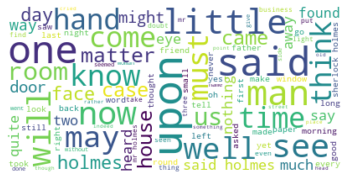

In [37]:
# wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt
% matplotlib inline

# Create and generate a word cloud image:
wordcloud = WordCloud(max_font_size=50, max_words=100, background_color="white").generate(text)
plt.figure()
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

# Save the image in the img folder:
# wordcloud.to_file("img/first_review.png")

In [86]:
# Save the Model
model.save('chgen_model_gru.h5')

### Model #2 (Replicate as necessary for other models)

In [ ]:
# Build the Model
# Enter your code here:


In [ ]:
# Train the Model
# Enter your code here:


In [ ]:
# Save the Model
model.save('chgen_model_2.h5')

## Step 3 – Use the Best Model to make prediction

In [ ]:
model.load_weights('chgen_model_best.h5')

In [ ]:
# takes the user input
text_input = np.array([input()])

In [ ]:
# one-hot encode the user input
# Enter your code here:


In [ ]:
# show the model output using predict function
# Enter your code here:
